In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import string
from FF_classifier import FFN
from dataset import Data

import matplotlib.pyplot as plt
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def plot_grid(model):
    x = np.linspace(0,1,1000)
    X, Y = np.meshgrid(x, x)
    
    dset = torch.tensor(np.vstack((X.flatten(), Y.flatten())).T, dtype = torch.float32)
    model.eval()
    Z = model(dset).detach().cpu().numpy().reshape((1000,1000))
    

    
    plt.figure(figsize=(8,6))
    plt.imshow(Z, extent=[0,1,0,1], origin='lower', cmap='inferno', aspect='auto')
    plt.colorbar(label='f(x,y)')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Heatmap of f(x,y) = sin(sqrt(x^2 + y^2))')
    plt.show()

def plot_grid_3D(model):
    x = np.linspace(0,1,1000)
    X, Y = np.meshgrid(x, x)
    
    dset = torch.tensor(np.vstack((X.flatten(), Y.flatten())).T, dtype = torch.float32)
    model.eval()
    Z = model(dset).detach().cpu().numpy().reshape((1000,1000))
    

    
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis')
    
    # Labels
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')
    ax.set_title('3D Surface Plot')
    
    # Show plot
    plt.show()



In [26]:


def f(X):
    return np.sin(X[:,0]) * np.cos(X[:,1]) + np.sin(X[:,1]) * np.cos(X[:,0]) + 1

s = 100000
X = torch.tensor(np.vstack((np.random.rand(s),np.random.rand(s))).T, dtype = torch.float32) * 4 * np.pi - (2 * np.pi) 
y = f(X).view(-1,1) 

dataset = Data(X,y, normalization = "uniform")

y.shape

torch.Size([100000, 1])

In [45]:

model = FFN([len(dataset.X[0]),32,16,1], dataset, device = device , 
            criterion = nn.MSELoss(), out_act = nn.Identity(), hidden_act = nn.LeakyReLU(),
           weight_decay = 0.0, dropout = None, lr = 0.01, batch_size = 256)

In [46]:
# Training loop
epochs_ , losses_, accs_ , lr_= [], [], [], []
X_test = dataset.X_test

Epoch [500/500], Loss: 0.0025, Lr: 0.0082

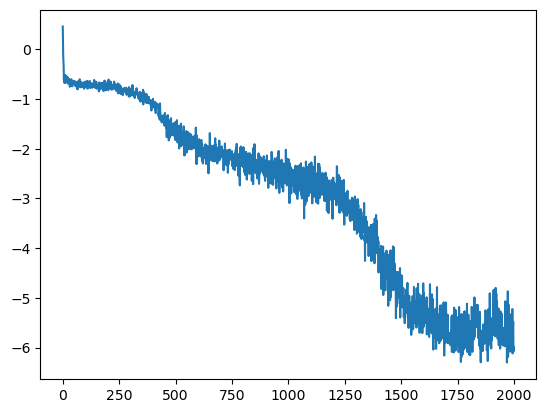

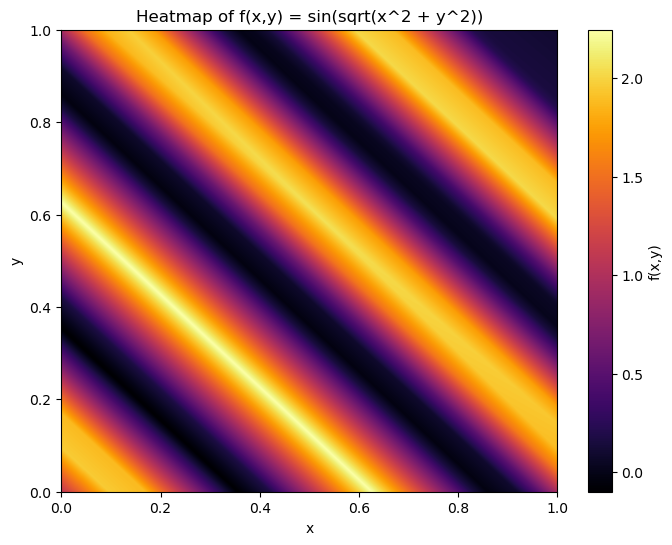

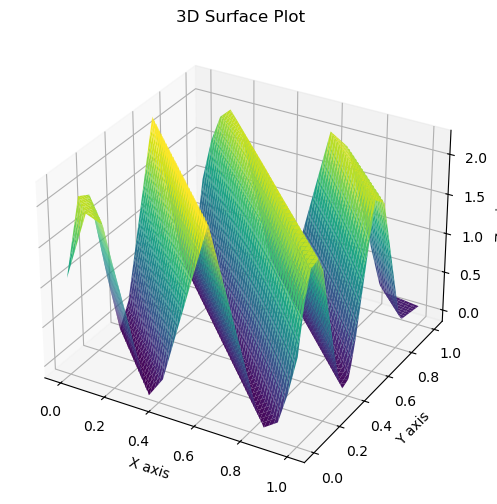

In [50]:
scheduler = optim.lr_scheduler.ExponentialLR(model.optimizer, gamma=1-0.0001)

epochs = 500
for epoch in range(epochs):
    loss = model.train_epoch()
    scheduler.step()
    lr = scheduler.get_last_lr()[0]
   
    

    if (epoch + 1) % 1 == 0:
        

        #loss, accuracy = model.test()
        print(f"\rEpoch [{epoch+1}/{epochs}], Loss: {loss:.4f}, Lr: {lr:.4f}",  end = "")
        #epochs_.append(epoch+1)
        losses_.append(loss.item())
        
plt.plot(np.log(losses_))
plt.show()
plot_grid(model)
plot_grid_3D(model)



plot_grid_3D(model)

In [258]:
model.model

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
  (3): ReLU()
  (4): Linear(in_features=1, out_features=1, bias=True)
  (5): Identity()
)

In [294]:
model.model[:-5]

Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
)

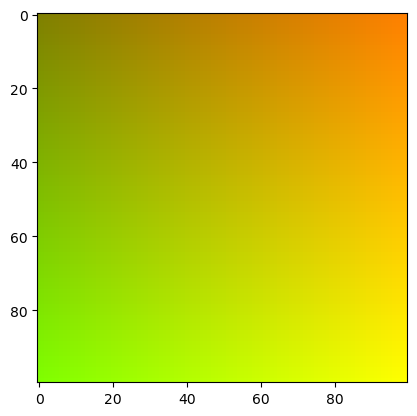

In [302]:
plt.imshow(colors)

Linear(in_features=2, out_features=2, bias=True)


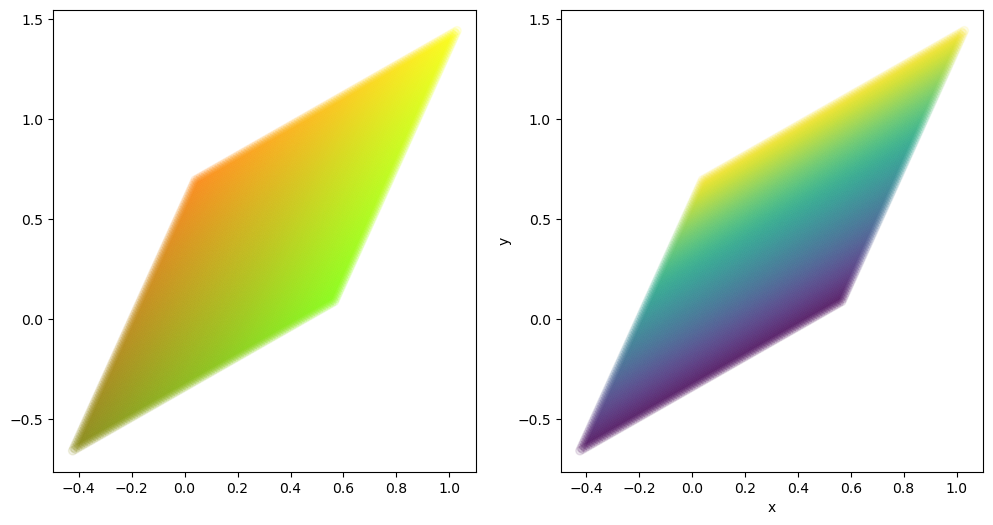

ReLU()


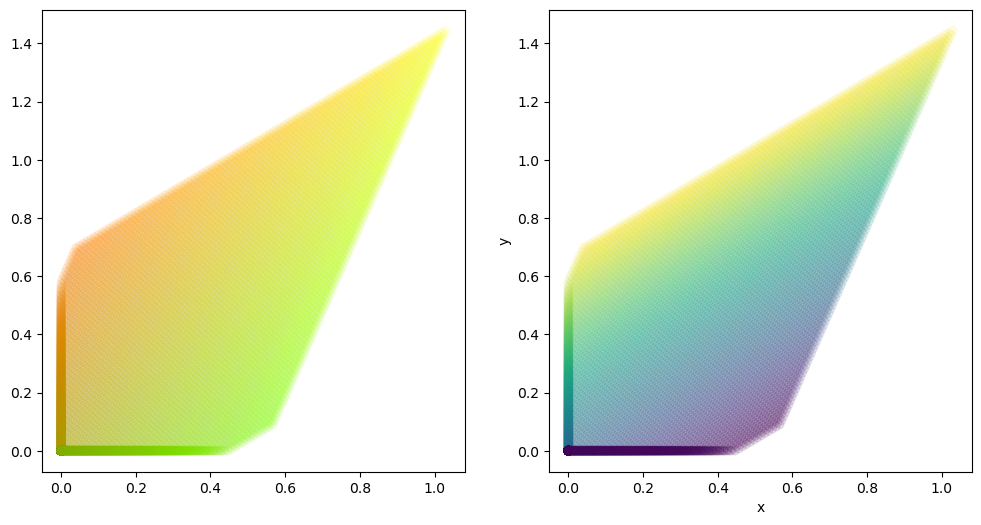

Linear(in_features=2, out_features=2, bias=True)


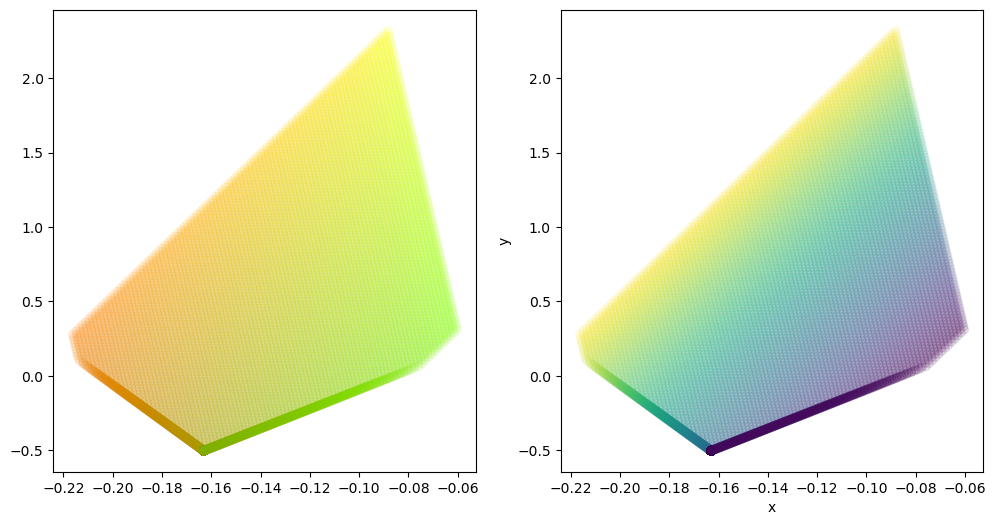

ReLU()


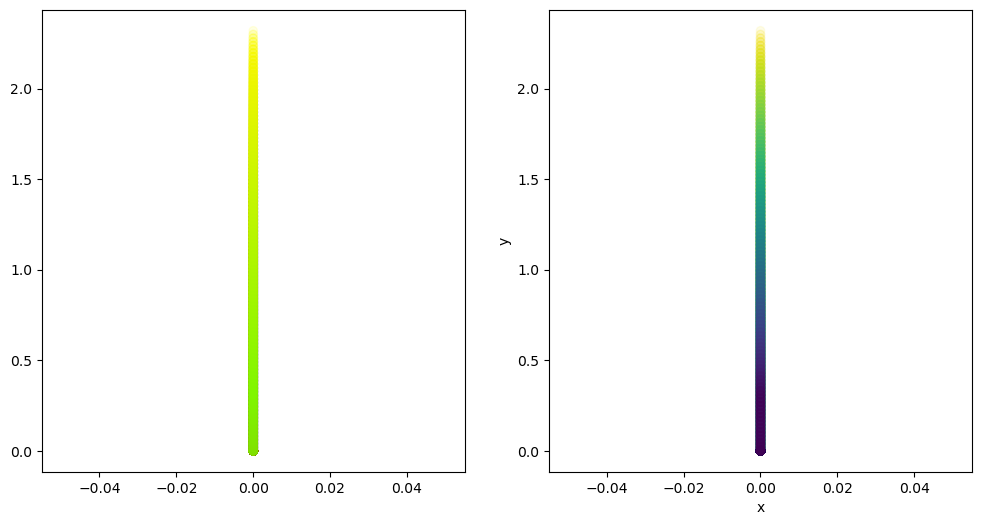

Linear(in_features=2, out_features=1, bias=True)


IndexError: index 1 is out of bounds for axis 1 with size 1

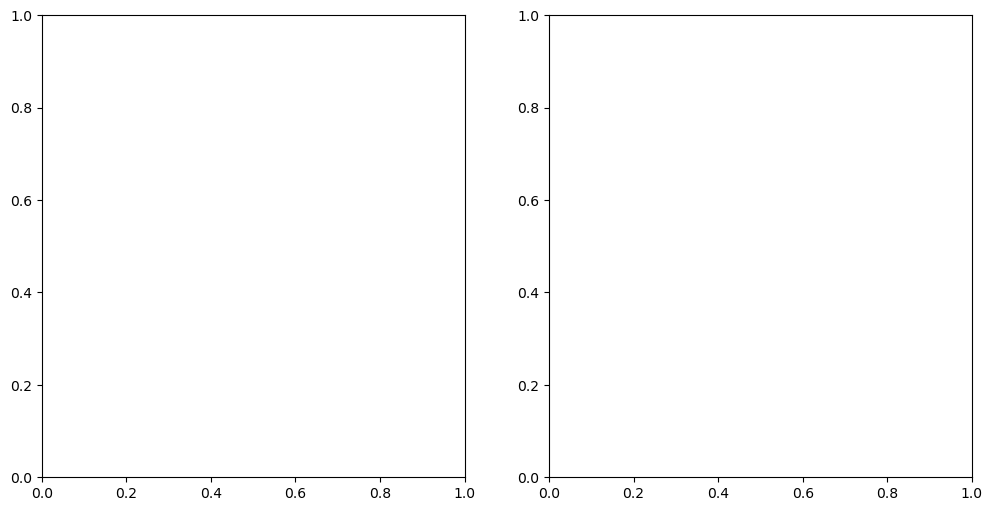

In [304]:
x = np.linspace(0,1,100)
X, Y = np.meshgrid(x, x)

colors = np.stack([(X + 1) / 2, (Y + 1) / 2, np.zeros_like(X)], axis=-1)

dset = torch.tensor(np.vstack((X.flatten(), Y.flatten())).T, dtype = torch.float32).to(model.device)
model.eval()

x = dset
for layer in model.model[:-1]:
    print(layer)
    x = layer(x)
    im = x.cpu().detach().numpy()

    fig, ax = plt.subplots(1,2,figsize=(12,6))
    ax[0].scatter(im[:,0],im[:,1], c = colors.reshape(-1,3), alpha = 0.1)
    ax[1].scatter(im[:,0],im[:,1], c = dset[:,0].cpu().numpy(), alpha = 0.1)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

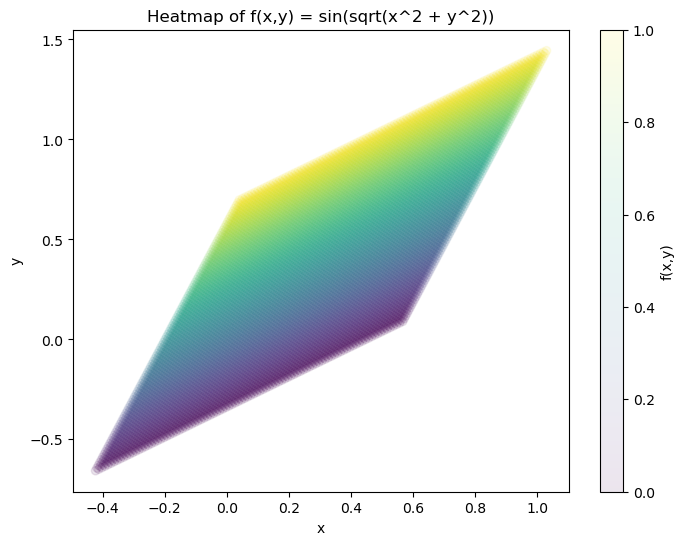

## Z.shape

In [6]:

for param_group in model.optimizer.param_groups:
    print(param_group['lr'])

0.01


In [ ]:
scheduler = optim.lr_scheduler.ExponentialLR(model.optimizer, gamma=1-0.0003)

model.reg = 0.0
epochs = 100000
for epoch in range(epochs):
    model.train_epoch()
    lr_.append(scheduler.get_last_lr()[0])
    
    scheduler.step()
    

    if (epoch + 1) % 10 == 0:
        loss, accuracy = model.test()
        loss = loss.mean().item()

        model.eval()
        outs = model(X_test)
        z_perc = (len(outs[outs==0]) / len(outs))
        
        print(f"\rEpoch [{epoch+1}/{epochs}], Loss: {loss:.4f}, Accuracy: {accuracy:.4f}, Z-perc : {z_perc:.4f} | lr : {scheduler.get_last_lr()[0]:.5f}", end = "")
        epochs_.append(epoch+1)
        losses_.append(loss)
        accs_.append(accuracy)
plt.plot(losses_)
plt.show()
plt.plot(accs_)
plt.show()
plt.plot(lr_)




Epoch [1610/100000], Loss: 9.9888, Accuracy: 0.9001, Z-perc : 0.6148 | lr : 0.006179

In [8]:
self=model
self.eval()
with torch.no_grad():
    outs = self(X_test)
print(len(outs[outs==0]) / len(outs))


0.6339712918660287


In [9]:
test_dfo = pd.read_csv("test.csv") 
pid = torch.tensor(test_dfo["PassengerId"].values, dtype = int)
output = torch.stack([pid,outs.view(-1).detach().cpu()], dim=1).to(int).numpy()

headers = ['PassengerId', 'Survived']
np.savetxt('output.csv', output, delimiter=',', fmt='%d', header=','.join(headers), comments='')  # `%d` for integer format

In [23]:

for batch in train_loader:
    inputs, targets = batch
    inputs, targets = inputs, targets  # Move to GPU if available
    print(f"Batch Inputs Shape: {inputs}, Batch Targets Shape: {targets}")
      # Show one batch and stop
    break

Batch Inputs Shape: tensor([[ 3.,  0., 21.],
        [ 3.,  0., 51.],
        [ 3.,  1.,  0.],
        [ 3.,  0.,  6.],
        [ 2.,  1., 29.],
        [ 3.,  1.,  0.],
        [ 2.,  1., 40.],
        [ 1.,  0.,  0.],
        [ 3.,  0.,  0.],
        [ 3.,  0.,  0.],
        [ 2.,  1.,  7.],
        [ 1.,  0., 70.],
        [ 3.,  0.,  0.],
        [ 3.,  0., 23.],
        [ 1.,  0., 40.],
        [ 1.,  1., 26.],
        [ 2.,  0., 29.],
        [ 3.,  1.,  5.],
        [ 1.,  0., 42.],
        [ 2.,  0., 25.],
        [ 3.,  0., 32.],
        [ 1.,  1., 35.],
        [ 3.,  1.,  0.],
        [ 3.,  0.,  0.],
        [ 3.,  0.,  0.],
        [ 2.,  0., 24.],
        [ 2.,  0., 62.],
        [ 3.,  0., 16.],
        [ 3.,  0.,  0.],
        [ 3.,  0., 24.],
        [ 1.,  0.,  0.],
        [ 1.,  0.,  0.]]), Batch Targets Shape: tensor([[0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
   

In [8]:
for i in model.test_loader:
    print(i)

Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/home/boz/anaconda3/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/home/boz/anaconda3/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/home/boz/anaconda3/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/boz/anaconda3/lib/python3.12/threading.py", line 1073, in _bootstrap_inner
    self.run()
  File "/home/boz/anaconda3/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 766, in run_closure


RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/boz/anaconda3/lib/python3.12/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/home/boz/anaconda3/lib/python3.12/site-packages/torch/utils/data/_utils/fetch.py", line 50, in fetch
    data = self.dataset.__getitems__(possibly_batched_index)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/boz/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataset.py", line 420, in __getitems__
    return [self.dataset[self.indices[idx]] for idx in indices]
            ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^
  File "/home/boz/Desktop/is/Keggle/Titanic/dataset.py", line 18, in __getitem__
    return self.X[idx], self.y[idx]
          ~~~~~~^^^^^
RuntimeError: CUDA error: initialization error
CUDA kernel errors might be asyn

    _threading_Thread_run(self)
  File "/home/boz/anaconda3/lib/python3.12/threading.py", line 1010, in run
    self._target(*self._args, **self._kwargs)
  File "/home/boz/anaconda3/lib/python3.12/multiprocessing/queues.py", line 291, in _feed
    queue_sem.release()
ValueError: semaphore or lock released too many times


In [4]:
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [5]:
len(dataset.X)

891

In [6]:
len(train_dataset)


712

In [7]:
len(test_dataset)

179

In [8]:
dl = DataLoader(train_dataset, batch_size = 16)

In [11]:
for batch in dl:
    print("a")

a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a
a


In [10]:
model.model

Sequential(
  (0): Linear(in_features=3, out_features=32, bias=True)
  (1): Sigmoid()
)